# Monitoring production et démonstration de drift

---

- **Projet 8 :** Confirmez vos compétences en MLOps (Partie 2/2)
- **Auteur :** Justine Tranchant
- **Date :** mars 2026

---

## Objectif

Ce notebook a deux usages :

- un **aperçu des logs de production** (`prediction_logs`, `environment = prod`) ;
- une **démonstration contrôlée de drift** entre la baseline et un lot drifté, avec Evidently.

Trois jeux sont manipulés :

- **`baseline`** — échantillon technique extrait de `test_enc.csv`, le split de test du modèle source. Sert de **jeu de référence**.
- **`prod`** — environnement de démonstration alimenté volontairement par injection (`scripts/inject_demo_requests.py`). **Ce n'est pas une vraie production métier.**
- **`monitoring_drift.csv`** — lot technique drifté artificiellement à partir de la baseline via `DRIFT_ADJUSTMENTS` (cf. détails repliables ci-dessous). Sert à la démonstration Evidently.

## Prérequis — générer et injecter les jeux de démo

Avant d'exécuter ce notebook, générer les jeux techniques et peupler la base (comme indiqué dans le README) :

1. Générer les deux jeux techniques de référence
```bash
poetry run python scripts/prepare_demo_data.py
```
2. Injecter les prédictions de démonstration en prod
```bash
poetry run python scripts/inject_demo_requests.py --environment prod --allow-demo-prod
```

> **Note** `prepare_demo_data.py` produit deux CSV : une baseline inchangée et un lot drift obtenu en appliquant des décalages contrôlés aux variables clés, définis dans `DRIFT_ADJUSTMENTS` :
>```python
>DRIFT_ADJUSTMENTS = {
>    "EXT_SOURCE_1": -0.12,
>    "EXT_SOURCE_2": -0.10,
>    "EXT_SOURCE_3": -0.11,
>    "AMT_CREDIT": 0.28,
>    "AMT_ANNUITY": 0.08,
>    "AMT_INCOME_TOTAL": -0.15,
>}
>```
>Deux modes d'application selon la variable :
>
>- **`EXT_SOURCE_*`** : décalage **additif** (`col + adjustment`), cohérent avec ces scores bornés à `[0, 1]`.
>- **`AMT_*`** : facteur **multiplicatif** `(1 + adjustment)` (ex. `+0.28` = +28 % sur `AMT_CREDIT`).
>
>Un bruit gaussien léger est ajouté dans les deux cas. Drift reproductible et explicable, que la section Evidently doit détecter.

</details>


## Imports et configuration


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

# Racine projet dans le path pour 'from src.database import ...'
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from IPython.display import display
from evidently import Report
from evidently.presets import DataDriftPreset

load_dotenv(PROJECT_ROOT / '.env')

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('Python :', sys.version.split()[0])
print('Projet :', PROJECT_ROOT)

Python : 3.12.13
Projet : /Users/wld/git/oc/oc_project8_mlops


## Chargement et préparation des données


### Baseline (jeu de référence)

Échantillon technique extrait de **`test_enc.csv`**, c'est-à-dire du **split de test du modèle source**. Versionné dans le repo, il sert de **jeu de référence** pour toutes les comparaisons du notebook.

Colonnes au format technique (majuscules, `DAYS_*` en entier négatif).


In [2]:
BASELINE_PATH = PROJECT_ROOT / 'data' / 'demo' / 'monitoring_baseline.csv'

baseline = pd.read_csv(BASELINE_PATH)
print('Baseline :', baseline.shape)
baseline.head(3)

Baseline : (100, 11)


,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_ID_PUBLISH,AMT_ANNUITY,AMT_GOODS_PRICE,AMT_CREDIT,AMT_INCOME_TOTAL,NAME_FAMILY_STATUS_is_MARRIED
0,0.7593,0.5715,0.2636,15319,999.0000,4849,17775.0000,225000.0000,225000.0000,337500.0000,1
1,0.8221,0.2740,0.3186,20498,2104.0000,3673,37930.5000,360000.0000,360000.0000,112500.0000,1
2,0.8220,0.3531,0.5937,18106,2857.0000,1654,29308.5000,904500.0000,904500.0000,315000.0000,1


### Logs de production

Logs lus via `src.database.read_prediction_logs()`, filtrés automatiquement sur `APP_ENV=prod`.

**`prod` est ici un environnement de démonstration** alimenté volontairement par `scripts/inject_demo_requests.py` — **ce n'est pas une production métier réelle**. Cet environnement sert uniquement à illustrer le pipeline de logging et les comparaisons baseline / prod.


In [15]:
import os
os.environ['APP_ENV'] = 'prod'

# Re-import pour que src.config relise APP_ENV depuis l'env var
import importlib
import src.config
import src.database
importlib.reload(src.config)
importlib.reload(src.database)
from src.database import read_prediction_logs

prod = read_prediction_logs(limit=10_000)
prod['timestamp'] = pd.to_datetime(prod['timestamp'])

print('Production :', prod.shape)
print('Environnements présents :', prod['environment'].unique())
prod.head(3)

Production : (200, 21)
Environnements présents : ['prod']


,id,timestamp,environment,score,label,threshold,ext_source_1,ext_source_2,ext_source_3,days_birth,...,days_id_publish,amt_annuity,amt_goods_price,amt_credit,amt_income_total,name_family_status_married,ratio_credit_annuity,ratio_goods_credit,ratio_annuity_income,duration_ms
0,3075,2026-04-15 07:23:21.100374+00:00,prod,0.0968,Crédit accordé,0.1000,0.4025,0.2463,0.5967,20892,...,4126,26454.8700,243000.0000,243000.0000,105018.3700,True,9.1855,1.0000,0.2519,7.3060
1,3074,2026-04-15 06:48:24.226936+00:00,prod,0.0360,Crédit accordé,0.1000,0.6531,0.6292,0.3812,20277,...,3808,42882.4400,1305000.0000,1305000.0000,192636.5200,True,30.4320,1.0000,0.2226,8.5660
2,3073,2026-04-15 06:31:03.012036+00:00,prod,0.5819,Crédit refusé,0.1000,0.0172,0.0525,0.0905,8396,...,1052,19143.2400,225000.0000,225000.0000,74446.6700,True,11.7535,1.0000,0.2571,7.9100


### Harmonisation des colonnes


In [4]:
baseline = baseline.rename(columns={c: c.lower() for c in baseline.columns})
baseline = baseline.rename(columns={'name_family_status_is_married': 'name_family_status_married'})

FEATURE_LABELS = {
    'ext_source_1': 'Score source externe 1',
    'ext_source_2': 'Score source externe 2',
    'ext_source_3': 'Score source externe 3',
    'days_birth': 'Âge du client',
    'days_employed': "Ancienneté dans l'emploi",
    'age_years': 'Âge du client',
    'employment_years': "Ancienneté dans l'emploi (années)",
    'amt_credit': 'Montant du crédit',
    'amt_income_total': 'Revenu total',
    'amt_annuity': 'Échéance annuelle',
    'ratio_credit_annuity': 'Ratio crédit / échéance annuelle',
}

FEATURES_NUM = [
    'ext_source_1', 'ext_source_2', 'ext_source_3',
    'days_birth', 'days_employed',
    'amt_credit', 'amt_income_total', 'amt_annuity',
]
FEATURE_BIN = 'name_family_status_married'

# Ratio credit/annuity : calculable côté prod directement, à calculer sur la baseline
baseline['ratio_credit_annuity'] = baseline['amt_credit'] / baseline['amt_annuity']
FEATURES_NUM.append('ratio_credit_annuity')

# Vérifie que toutes les colonnes existent des deux côtés
missing_baseline = [c for c in FEATURES_NUM + [FEATURE_BIN] if c not in baseline.columns]
missing_prod = [c for c in FEATURES_NUM + [FEATURE_BIN] if c not in prod.columns]
print('Colonnes manquantes baseline :', missing_baseline)
print('Colonnes manquantes prod     :', missing_prod)

Colonnes manquantes baseline : []
Colonnes manquantes prod     : []


### Harmonisation du signe des variables `DAYS_`

Les logs applicatifs stockent `days_birth`, `days_employed`, `days_id_publish` avec le signe Home Credit (valeurs négatives). La baseline est ré-alignée sur ce référentiel si nécessaire, puis on calcule `age_years` et `employment_years` pour une lecture plus directe.


In [5]:
DAY_COLUMNS = ['days_birth', 'days_employed', 'days_id_publish']

for col in DAY_COLUMNS:
    if col in baseline.columns and col in prod.columns:
        baseline_median = baseline[col].median()
        prod_median = prod[col].median()
        if pd.notna(baseline_median) and pd.notna(prod_median):
            if np.sign(baseline_median) != np.sign(prod_median):
                baseline[col] = -baseline[col]

NUMERIC_COLUMNS = FEATURES_NUM + ['days_id_publish', FEATURE_BIN]

for df in [baseline, prod]:
    for col in NUMERIC_COLUMNS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

for df in [baseline, prod]:
    df['age_years'] = (df['days_birth'].abs() / 365.25).round().astype('Int64')
    df['employment_years'] = (df['days_employed'].abs() / 365.25).round(1)

FEATURES_NUM = [
    'ext_source_1', 'ext_source_2', 'ext_source_3',
    'age_years', 'employment_years',
    'amt_credit', 'amt_income_total', 'amt_annuity',
    'ratio_credit_annuity',
]

baseline[['age_years', 'employment_years']].describe().T

,count,mean,std,min,25%,50%,75%,max
age_years,100.0000,38.1400,8.8249,24.0000,31.0000,38.0000,43.0000,61.0000
employment_years,100.0000,6.9560,5.0142,0.4000,2.7750,6.1000,10.0500,22.7000


## Aperçu de la production


In [6]:
total = len(prod)
accepted = (prod['label'] == 'Crédit accordé').sum()
refused = (prod['label'] == 'Crédit refusé').sum()
period_start = prod['timestamp'].min()
period_end = prod['timestamp'].max()

summary = pd.DataFrame({
    'metric': [
        'Prédictions totales', 'Accordées', 'Refusées',
        "Taux d'acceptation", 'Score moyen', 'Score médian',
        'Période début', 'Période fin', 'Nb de jours couverts',
    ],
    'valeur': [
        total, accepted, refused,
        f'{accepted / total:.1%}' if total else 'n/a',
        f"{prod['score'].mean():.4f}",
        f"{prod['score'].median():.4f}",
        period_start, period_end,
        prod['timestamp'].dt.date.nunique(),
    ],
})
summary

,metric,valeur
0,Prédictions totales,200
1,Accordées,119
2,Refusées,81
3,Taux d'acceptation,59.5%
4,Score moyen,0.1121
5,Score médian,0.0693
6,Période début,2026-03-26 09:39:11.395609+00:00
7,Période fin,2026-04-15 07:23:21.100374+00:00
8,Nb de jours couverts,21


### Volume temporel


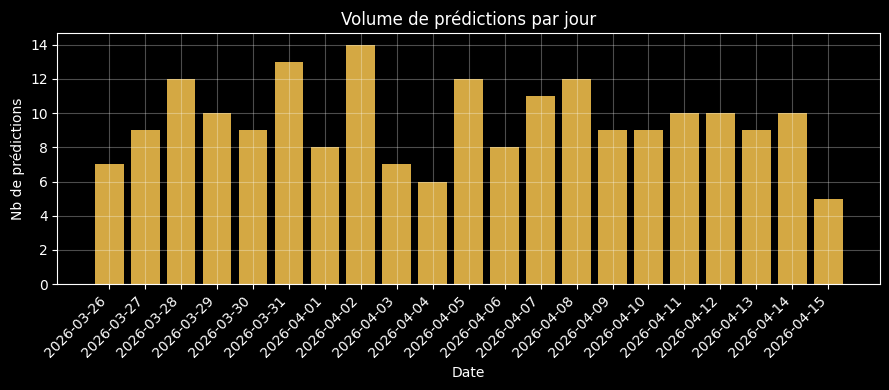

,date,volume
0,2026-03-26,7
1,2026-03-27,9
2,2026-03-28,12
3,2026-03-29,10
4,2026-03-30,9
5,2026-03-31,13
6,2026-04-01,8
7,2026-04-02,14
8,2026-04-03,7
9,2026-04-04,6


In [7]:
daily = (
    prod.assign(date=prod['timestamp'].dt.date)
        .groupby('date').size()
        .rename('volume').reset_index()
)

fig, ax = plt.subplots()
ax.bar(daily['date'].astype(str), daily['volume'], color='#D4A843')
ax.set_title('Volume de prédictions par jour')
ax.set_xlabel('Date')
ax.set_ylabel('Nb de prédictions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

daily

Volume de démonstration : suffisant pour vérifier le pipeline de logging, pas pour une lecture statistique robuste.


### Distribution des scores


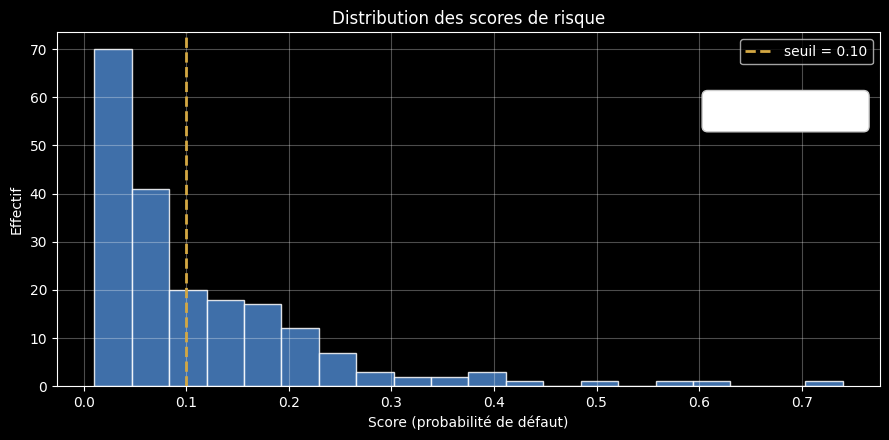

In [8]:
if prod.empty:
    print('Aucun log prod disponible pour la distribution des scores.')
    pd.DataFrame(columns=['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max'], index=['score_prod'])
else:
    threshold = prod['threshold'].iloc[0]
    approved_count = (prod['label'] == 'Crédit accordé').sum()
    refused_count = (prod['label'] == 'Crédit refusé').sum()

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.hist(prod['score'], bins=20, color='#4B83C8', edgecolor='white', alpha=0.85)
    ax.axvline(threshold, color='#D4A843', linestyle='--', linewidth=2,
               label=f'seuil = {threshold:.2f}')
    ax.set_title('Distribution des scores de risque')
    ax.set_xlabel('Score (probabilité de défaut)')
    ax.set_ylabel('Effectif')
    ax.legend(loc='upper right')
    summary_text = f"Crédits accordés : {approved_count}\nCrédits refusés : {refused_count}"
    ax.text(0.98, 0.82, summary_text, transform=ax.transAxes, ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#CCCCCC'))
    plt.tight_layout()
    plt.show()

    prod['score'].describe().to_frame('score_prod').T

Rappel rapide :

- `age_years` / `employment_years` : versions lisibles de `days_birth` et `days_employed`.
- `ratio_credit_annuity` : indicateur simple de charge financière.


## Comparaison baseline vs production

On compare ici la **baseline** (issue du split de test `test_enc.csv`) aux logs de l'environnement de démonstration **`prod`**.

Pour chaque feature numérique, superposition des histogrammes normalisés, complétée par un tableau de statistiques comparées.


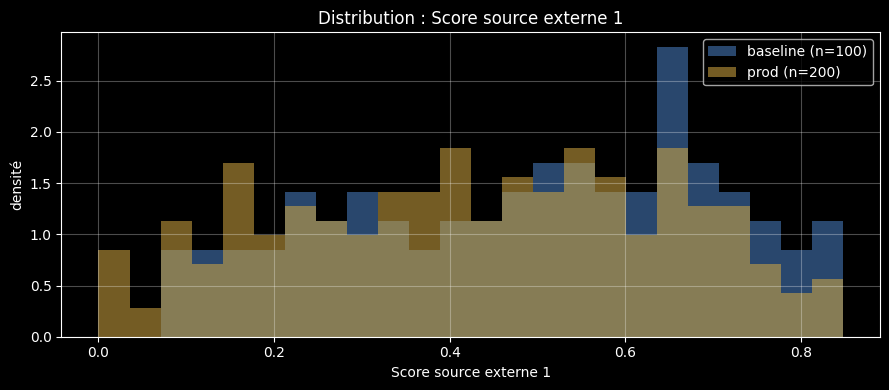

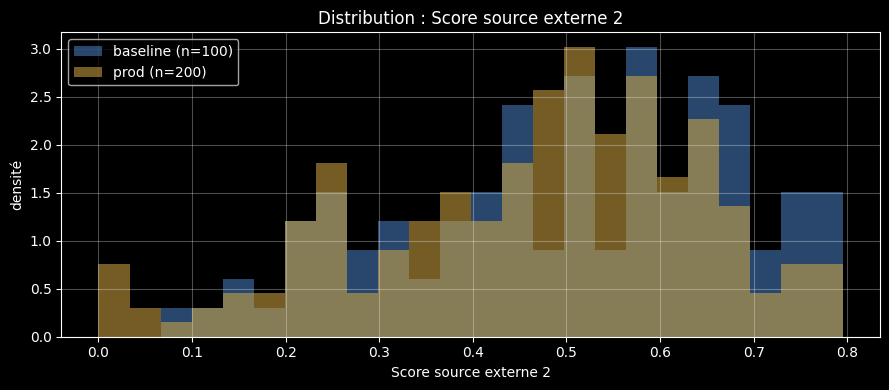

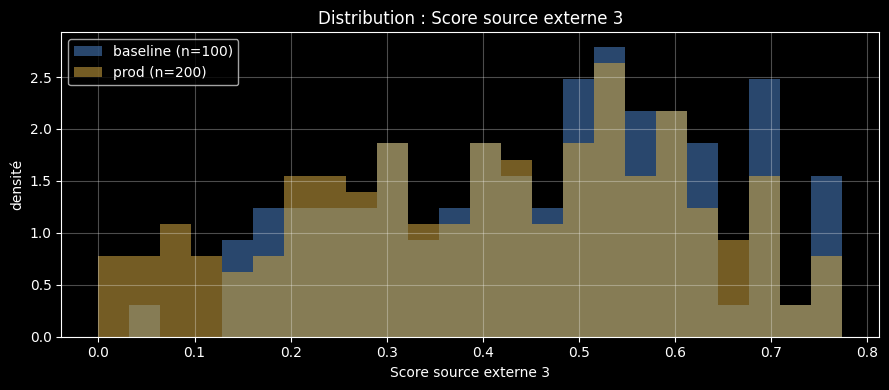

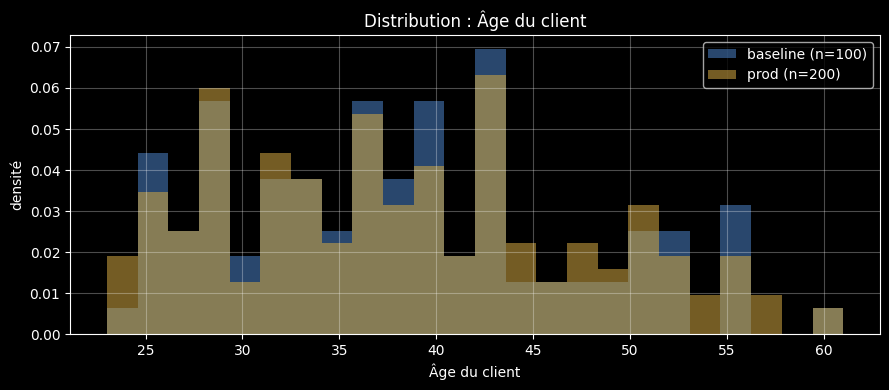

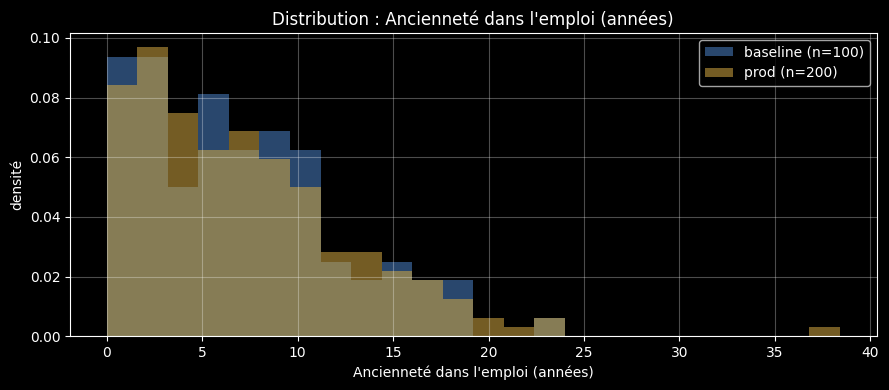

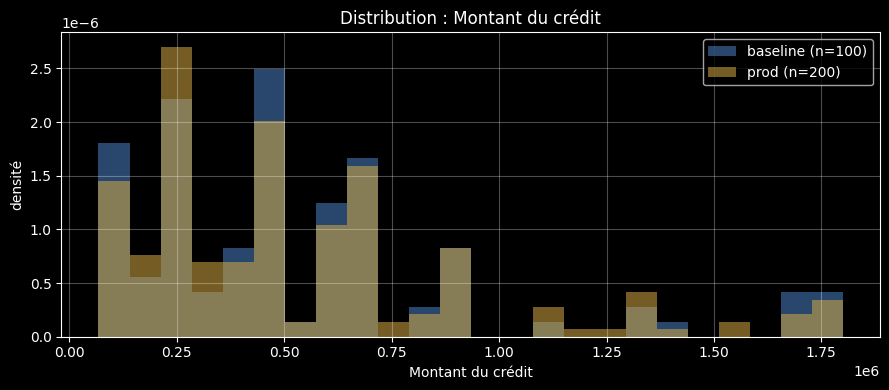

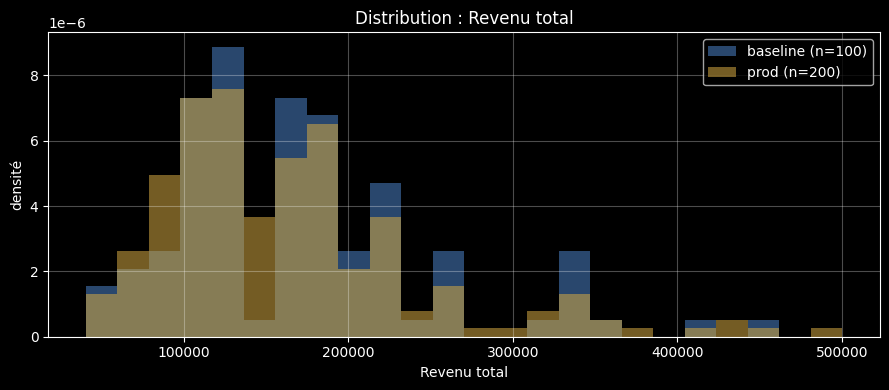

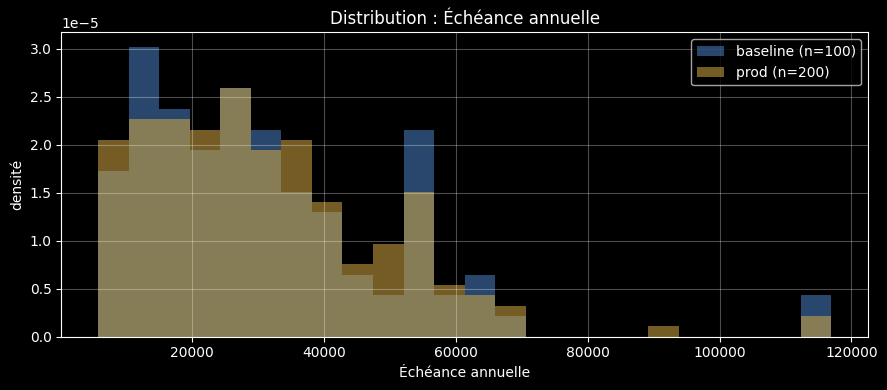

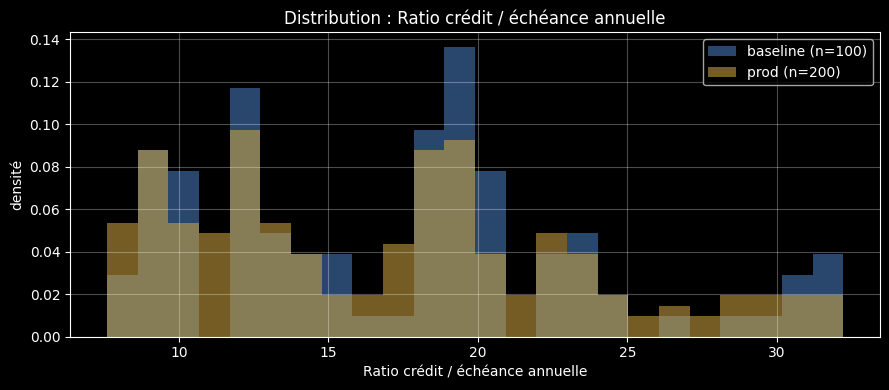

In [9]:
def compare_numeric(col: str) -> None:
    a = baseline[col].dropna()
    b = prod[col].dropna()
    lo = min(a.min(), b.min())
    hi = max(a.max(), b.max())
    bins = np.linspace(lo, hi, 25)
    fig, ax = plt.subplots()
    ax.hist(a, bins=bins, alpha=0.55, label=f'baseline (n={len(a)})',
            color='#4B83C8', density=True)
    ax.hist(b, bins=bins, alpha=0.55, label=f'prod (n={len(b)})',
            color='#D4A843', density=True)
    label = FEATURE_LABELS.get(col, col)
    ax.set_title(f'Distribution : {label}')
    ax.set_xlabel(label)
    ax.set_ylabel('densité')
    ax.legend()
    plt.tight_layout()
    plt.show()

for col in FEATURES_NUM:
    compare_numeric(col)

### Statistiques comparées


In [10]:
def stats_row(name: str, s: pd.Series) -> dict:
    return {
        'variable': FEATURE_LABELS.get(name, name),
        'mean_baseline': baseline[name].mean(),
        'mean_prod': prod[name].mean(),
        'median_baseline': baseline[name].median(),
        'median_prod': prod[name].median(),
    }

rows = [stats_row(c, None) for c in FEATURES_NUM]
stats = pd.DataFrame(rows)
stats['delta_mean_pct'] = 100 * (stats['mean_prod'] - stats['mean_baseline']) \
                              / stats['mean_baseline'].replace(0, np.nan)
stats.round(3)

,variable,mean_baseline,mean_prod,median_baseline,median_prod,delta_mean_pct
0,Score source externe 1,0.4910,0.4300,0.5130,0.4410,-12.3880
1,Score source externe 2,0.5030,0.4640,0.5190,0.4970,-7.7790
2,Score source externe 3,0.4630,0.4080,0.4900,0.4250,-11.8660
3,Âge du client,38.1400,38.3800,38.0000,38.0000,0.6290
4,Ancienneté dans l'emploi (années),6.9560,7.2350,6.1000,6.0500,4.0040
5,Montant du crédit,544005.0000,539640.0000,450000.0000,450000.0000,-0.8020
6,Revenu total,172559.3400,165960.0450,157500.0000,152295.2450,-3.8240
7,Échéance annuelle,31070.3400,30947.7200,25625.2500,27578.5550,-0.3950
8,Ratio crédit / échéance annuelle,17.3930,16.9830,17.9100,17.3610,-2.3590


### Variable binaire : `name_family_status_married`

Comparaison des proportions entre baseline et prod.


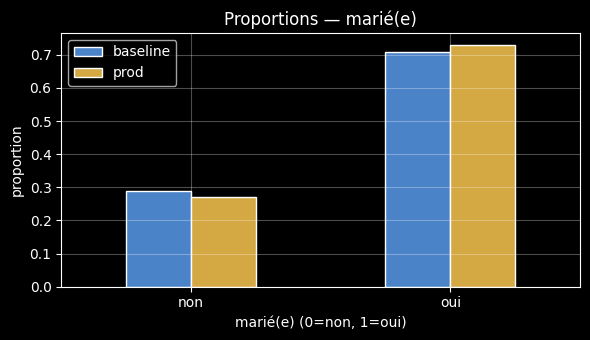

,baseline,prod
name_family_status_married,,
0.0000,0.2900,0.2700
1.0000,0.7100,0.7300


In [11]:
bin_stats = pd.DataFrame({
    'baseline': baseline[FEATURE_BIN].astype(float).value_counts(normalize=True),
    'prod': prod[FEATURE_BIN].astype(float).value_counts(normalize=True),
}).fillna(0.0).sort_index()

fig, ax = plt.subplots(figsize=(6, 3.5))
bin_stats.plot(kind='bar', ax=ax, color=['#4B83C8', '#D4A843'], edgecolor='white')
ax.set_title('Proportions — marié(e)')
ax.set_xlabel('marié(e) (0=non, 1=oui)')
ax.set_ylabel('proportion')
ax.set_xticklabels(['non', 'oui'], rotation=0)
plt.tight_layout()
plt.show()
bin_stats

## Drift contrôlé avec Evidently

Cette section ne compare **pas** baseline vs prod. Elle compare :

- la **`baseline`** (split de test du modèle source) ;
- le lot **`monitoring_drift.csv`**, obtenu en appliquant `DRIFT_ADJUSTMENTS` à la baseline (cf. en-tête du notebook).

L'objectif est de montrer qu'Evidently détecte bien un drift **volontairement injecté**. Une p-value inférieure au seuil `0.05` signale une dérive détectée.


In [12]:
DRIFT_TECHNICAL_PATH = PROJECT_ROOT / 'data' / 'demo' / 'monitoring_drift.csv'

drift_technical = pd.read_csv(DRIFT_TECHNICAL_PATH)
drift_technical = drift_technical.rename(columns={c: c.lower() for c in drift_technical.columns})
drift_technical = drift_technical.rename(columns={'name_family_status_is_married': 'name_family_status_married'})
drift_technical['ratio_credit_annuity'] = drift_technical['amt_credit'] / drift_technical['amt_annuity']

for col in DAY_COLUMNS:
    if col in drift_technical.columns and col in baseline.columns:
        drift_median = drift_technical[col].median()
        baseline_median = baseline[col].median()
        if pd.notna(drift_median) and pd.notna(baseline_median):
            if np.sign(drift_median) != np.sign(baseline_median):
                drift_technical[col] = -drift_technical[col]

drift_technical['age_years'] = (drift_technical['days_birth'].abs() / 365.25).round().astype('Int64')
drift_technical['employment_years'] = (drift_technical['days_employed'].abs() / 365.25).round(1)

print('Drift technique contrôlé :', drift_technical.shape)
drift_technical.head(3)

Drift technique contrôlé : (100, 14)


,ext_source_1,ext_source_2,ext_source_3,days_birth,days_employed,days_id_publish,amt_annuity,amt_goods_price,amt_credit,amt_income_total,name_family_status_married,ratio_credit_annuity,age_years,employment_years
0,0.2106,0.6075,0.6681,18911,1018.0000,2464,47700.0600,454500.0000,454500.0000,179167.6400,1,9.5283,52,2.8000
1,0.0999,0.2062,0.3161,9387,177.0000,1589,27034.4600,315000.0000,315000.0000,86409.8900,1,11.6518,26,0.5000
2,0.1535,0.3800,0.2692,10838,1343.0000,1697,36744.7100,315000.0000,315000.0000,149697.5900,1,8.5727,30,3.7000


,Variables testées,Variables en drift,Part des variables en drift
0,5,4,80.0%


,Variable,p-value Evidently,Seuil,Drift détecté
0,Score source externe 1,0.0022,0.05,Oui
1,Score source externe 2,0.0037,0.05,Oui
2,Score source externe 3,0.0156,0.05,Oui
3,Revenu total,0.0156,0.05,Oui
4,Ratio crédit / échéance annuelle,0.1548,0.05,Non


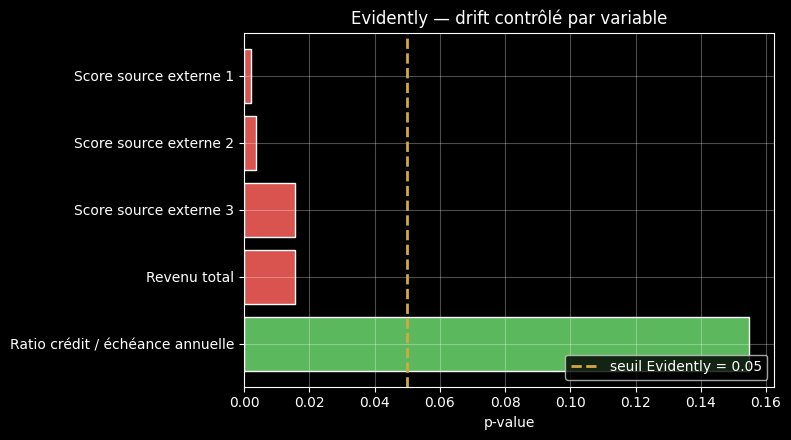

In [13]:
EVIDENTLY_FEATURES = [
    'ext_source_1',
    'ext_source_2',
    'ext_source_3',
    #'age_years',
    #'employment_years',
    #'amt_credit',
    'amt_income_total',
    #'amt_annuity',
    'ratio_credit_annuity',
]

reference_data = baseline[EVIDENTLY_FEATURES].copy().astype(float)
current_data = drift_technical[EVIDENTLY_FEATURES].copy().astype(float)

evidently_snapshot = Report([DataDriftPreset()]).run(reference_data, current_data)
evidently_result = evidently_snapshot.dict()

dataset_drift_metric = evidently_result['metrics'][0]
evidently_summary = pd.DataFrame([
    {
        'Variables testées': len(EVIDENTLY_FEATURES),
        'Variables en drift': int(dataset_drift_metric['value']['count']),
        'Part des variables en drift': dataset_drift_metric['value']['share'],
    }
])

evidently_rows = []
for metric in evidently_result['metrics'][1:]:
    column = metric['config']['column']
    threshold = metric['config']['threshold']
    p_value = float(metric['value'])
    drift_detected = p_value < threshold
    evidently_rows.append(
        {
            'Variable': FEATURE_LABELS.get(column, column),
            'p-value Evidently': p_value,
            'Seuil': threshold,
            'Drift détecté': 'Oui' if drift_detected else 'Non',
            '_drift_detected': drift_detected,
        }
    )

evidently_feature_drift_df = pd.DataFrame(evidently_rows).sort_values(
    by=['_drift_detected', 'p-value Evidently'],
    ascending=[False, True],
).drop(columns=['_drift_detected'])

display(evidently_summary.style.format({'Part des variables en drift': '{:.1%}'}))
display(evidently_feature_drift_df.style.format({'p-value Evidently': '{:.4f}', 'Seuil': '{:.2f}'}))

plot_df = evidently_feature_drift_df.sort_values('p-value Evidently', ascending=True)
colors = plot_df['Drift détecté'].map({'Oui': '#D9534F', 'Non': '#5CB85C'})

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(plot_df['Variable'], plot_df['p-value Evidently'], color=colors, edgecolor='white')
ax.axvline(0.05, color='#D4A843', linestyle='--', linewidth=2, label='seuil Evidently = 0.05')
ax.set_title('Evidently — drift contrôlé par variable')
ax.set_xlabel('p-value')
ax.legend(loc='lower right')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [14]:
diagnostic_cols = [
    'ext_source_1',
    'ext_source_2',
    'ext_source_3',
    'amt_credit',
    'amt_annuity',
    'amt_income_total',
    'ratio_credit_annuity',
    'age_years',
    'employment_years',
]

rows = []
for col in diagnostic_cols:
    rows.append({
        'variable': FEATURE_LABELS.get(col, col),
        'mean_baseline': baseline[col].mean(),
        'mean_drift': drift_technical[col].mean(),
        'median_baseline': baseline[col].median(),
        'median_drift': drift_technical[col].median(),
    })

diag = pd.DataFrame(rows)
diag['delta_mean_abs'] = diag['mean_drift'] - diag['mean_baseline']
diag['delta_mean_pct'] = 100 * diag['delta_mean_abs'] / diag['mean_baseline'].replace(0, np.nan)
diag.round(3)

,variable,mean_baseline,mean_drift,median_baseline,median_drift,delta_mean_abs,delta_mean_pct
0,Score source externe 1,0.4910,0.3690,0.5130,0.3800,-0.1220,-24.7760
1,Score source externe 2,0.5030,0.4250,0.5190,0.4730,-0.0780,-15.5580
2,Score source externe 3,0.4630,0.3530,0.4900,0.3560,-0.1100,-23.7330
3,Montant du crédit,544005.0000,535275.0000,450000.0000,450000.0000,-8730.0000,-1.6050
4,Échéance annuelle,31070.3400,30825.1010,25625.2500,28735.9000,-245.2390,-0.7890
5,Revenu total,172559.3400,159360.7510,157500.0000,137957.9050,-13198.5890,-7.6490
6,Ratio crédit / échéance annuelle,17.3930,16.5720,17.9100,16.4970,-0.8210,-4.7180
7,Âge du client,38.1400,38.6200,38.0000,38.0000,0.4800,1.2590
8,Ancienneté dans l'emploi (années),6.9560,7.5130,6.1000,5.7000,0.5570,8.0070


Lecture : démonstration **contrôlée** — elle montre qu'Evidently détecte le drift injecté dans `monitoring_drift.csv`. Elle ne remplace pas un suivi réel de production.


## Conclusion

- Le pipeline de logging `prediction_logs` fonctionne côté `prod` (environnement de démonstration alimenté par injection).
- La **baseline** (split de test `test_enc.csv`) et les **logs `prod`** sont comparables après harmonisation des colonnes et du signe des variables `DAYS_`.
- Evidently détecte bien la dérive sur **`monitoring_drift.csv`** (lot drifté contrôlé via `DRIFT_ADJUSTMENTS`), ce qui valide l'outil comme brique de monitoring de dérive.
